<a href="https://colab.research.google.com/github/Andrew-lee0615/Quant-Analysis-Python/blob/main/06_gas_price_impact_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[                       0%                       ]

--- 데이터 다운로드 중 ---


[*********************100%***********************]  4 of 4 completed
/tmp/ipykernel_2367/3916018614.py:15: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()



   [Gas Shock Days & Sector Performance]   
Ticker          NG=F       XLE       XLI    Spread
Date                                              
2026-01-26  0.289100  0.000610  0.000974 -0.000364
2026-01-20  0.259104 -0.001887 -0.020192  0.018304
2026-01-21  0.247760  0.024160  0.017306  0.006854
2025-10-30  0.171801 -0.005908 -0.002515 -0.003394
2025-12-23  0.111728  0.006560 -0.000382  0.006942
2026-01-30  0.111281  0.010691 -0.002532  0.013223
2026-01-12  0.075734 -0.007071  0.007658 -0.014729
2025-12-29  0.073523  0.009502 -0.002163  0.011665
2026-01-28  0.072764  0.007650 -0.005574  0.013224
2025-11-28  0.064063  0.013105  0.005825  0.007280
2026-03-11  0.062583  0.024820 -0.003117  0.027937
2026-03-06  0.060939  0.001593 -0.012321  0.013915
2025-11-11  0.052328  0.013060  0.000259  0.012801
2026-01-07  0.052239 -0.011174 -0.018825  0.007651
2026-02-04  0.046512  0.022450  0.002664  0.019787
2026-01-23  0.045590  0.005725 -0.007734  0.013459
2025-12-05  0.044638 -0.004121 -0.002

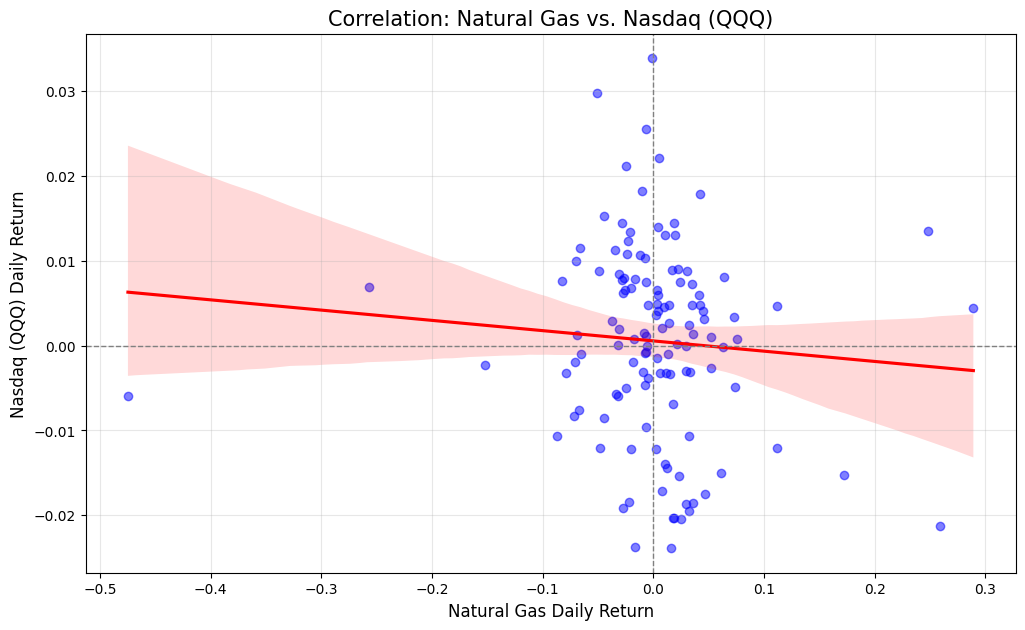

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 (천연가스, 에너지섹터, 제조업섹터, 나스닥)
print("--- 데이터 다운로드 중 ---")
tickers = ['NG=F', 'XLE', 'XLI', 'QQQ']

# 수정 포인트: auto_adjust=True를 사용하여 'Adj Close' 대신 'Close'를 바로 사용 가능하게 함
raw_data = yf.download(tickers, period='6mo', auto_adjust=True)

# 2. 'Close' 가격만 추출하고 일일 수익률 계산
data = raw_data['Close']
returns = data.pct_change().dropna()

# 3. 'Gas Shock' 분석: 가스 가격이 3% 이상 폭등한 날 필터링
# 에너지(XLE)와 제조업(XLI)의 수익률 차이(Spread)를 계산
gas_shocks = returns[returns['NG=F'] >= 0.03].copy()
gas_shocks['Spread'] = gas_shocks['XLE'] - gas_shocks['XLI']

print("\n" + "="*50)
print("   [Gas Shock Days & Sector Performance]   ")
print("="*50)
# 결과 출력 (데이터가 있는 경우에만)
if not gas_shocks.empty:
    print(gas_shocks[['NG=F', 'XLE', 'XLI', 'Spread']].sort_values(by='NG=F', ascending=False))
else:
    print("최근 6개월 내에 가스 가격이 3% 이상 폭등한 날이 없습니다.")
print("="*50)

# 4. 결과 해석 출력
if not gas_shocks.empty:
    avg_spread = gas_shocks['Spread'].mean()
    print(f"\n💡 가스 폭등 시 에너지주 vs 제조업주 평균 수익률 격차: {avg_spread:.4f}")
    if avg_spread > 0:
        print("👉 가설 입증: 에너지 섹터가 제조업보다 강세를 보였습니다.")
    else:
        print("👉 가설 재검토 필요: 섹터 간 양극화가 뚜렷하지 않습니다.")

# 5. 시각화: 가스 가격과 나스닥의 상관관계
plt.figure(figsize=(12, 7))
sns.regplot(x=returns['NG=F'], y=returns['QQQ'],
            scatter_kws={'alpha':0.5, 'color':'blue'},
            line_kws={'color':'red'})

plt.title('Correlation: Natural Gas vs. Nasdaq (QQQ)', fontsize=15)
plt.xlabel('Natural Gas Daily Return', fontsize=12)
plt.ylabel('Nasdaq (QQQ) Daily Return', fontsize=12)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.show()